<a href="https://colab.research.google.com/github/hoangchaulanbao/HocmayNC/blob/main/DANG_THI_KIM_HOANG_MLPCar_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BÁO CÁO THỰC NGHIỆM: PHÂN LOẠI GIÁ XE Ô TÔ SỬ DỤNG MẠNG NƠ-RON ĐA TẦNG MULTI-LAYER PERCEPTRON (MLP)
* **Môn học:** Học máy Nâng cao
* **Thành viên thực hiện:** ĐẶNG THỊ KIM HOÀNG

---

## GIỚI THIỆU BÀI TOÁN
Trong nền kinh tế số, việc xác định phân khúc giá của phương tiện giao thông đóng vai trò cốt lõi trong các hệ thống định giá tự động, sàn thương mại điện tử ô tô cũ và hệ thống gợi ý sản phẩm (Recommendation Systems).

Ban đầu, thuộc tính giá xe (`Price`) trong tập dữ liệu thực tế là một biến liên tục (bài toán Hồi quy). Tuy nhiên, để tối ưu hóa quyết định kinh doanh phân khúc, báo cáo này tiến hành cấu trúc lại bài toán thành **Phân loại đa lớp (Multi-class Classification)** bằng cách rời rạc hóa mục tiêu thành 3 phân khúc: **Thấp (Low)**, **Trung bình (Medium)**, và **Cao (High)** dựa trên phân phối thực nghiệm của dữ liệu.

## MỤC TIÊU:

- Xây dựng pipeline tiền xử lý đảm bảo không có **data leakage**.
- Thiết kế mô hình **Multi-Layer Perceptron (MLP)** với ít nhất 2 hidden layers.
- Sử dụng hàm kích hoạt **ReLU** để tạo tính phi tuyến.
- Tích hợp kỹ thuật **Dropout** nhằm giảm hiện tượng overfitting.
- So sánh hiệu quả giữa mô hình **có Dropout** và **không Dropout**.
- Đánh giá mô hình bằng các chỉ số:
  - **Confusion Matrix**
  - **Precision**
  - **Recall**
  - **F1-score**
  - **Precision–Recall Curve**
- Phân tích sự đánh đổi (trade-off) giữa **Precision và Recall** trong bối cảnh bài toán thực tế.

# **#SECTION 1. SETUP ENVIRONMENT & IMPORT LIBRARIES**

Khai báo các thư viện cần thiết cho xử lý dữ liệu, trực quan hóa và xây dựng mô hình Deep Learning.

Thiết lập `random seed = 42` nhằm đảm bảo tính tái lập kết quả thực nghiệm.

In [108]:
# ============================================
# SECTION 1. SETUP ENVIRONMENT & IMPORT LIBRARIES
# ============================================

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn

from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)

# ============================================
# 1.2 ENVIRONMENT CONFIGURATION (SEED)
# ============================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Đảm bảo tính tái lập tuyệt đối trên GPU
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Môi trường sẵn sàng! Thiết bị tính toán: {device}")

Môi trường sẵn sàng! Thiết bị tính toán: cpu


# **# SECTION 2. DATA UNDERSTANDING & TRAIN-TEST SPLIT**

- Đọc và kiểm tra dữ liệu đầu vào.
- Kiểm tra dữ liệu khuyết thiếu (NaN) để đảm bảo chất lượng dữ liệu.
- Chia dữ liệu theo tỷ lệ 80% Train và 20% Validation theo hướng anti-data leakage trước bước tiền xử lý.

Tập Validation được giữ độc lập để đánh giá mô hình.

#  Load và hiển thị 5 dòng data

In [109]:
# Load data
DATA_URL = "https://raw.githubusercontent.com/hoangchaulanbao/HocmayNC/main/car_sales_data.csv"

try:
    # 2. Đọc dữ liệu từ URL
    df = pd.read_csv(DATA_URL)

    # 3. Hiển thị thông tin kích thước
    print(f"Kích thước Dataset: {df.shape[0]:,} dòng | {df.shape[1]:,} cột\n")

    # 4. Hiển thị 5 dòng đầu tiên
    display(df.head()) # Sử dụng df.head() nếu chạy trên script .py thông thường

except Exception as e:
    print(f"Lỗi: Không thể tải dữ liệu từ URL. Chi tiết: {e}")

Kích thước Dataset: 50,000 dòng | 7 cột



,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price
0,Ford,Fiesta,1.0,Petrol,2002,127300,3074
1,Porsche,718 Cayman,4.0,Petrol,2016,57850,49704
2,Ford,Mondeo,1.6,Diesel,2014,39190,24072
3,Toyota,RAV4,1.8,Hybrid,1988,210814,1705
4,VW,Polo,1.0,Petrol,2006,127869,4101


## Tổng quan dữ liệu

Phần này thực hiện kiểm tra sơ bộ tập dữ liệu bao gồm kích thước, kiểu dữ liệu và một số bản ghi đầu tiên nhằm hiểu cấu trúc dữ liệu trước khi tiền xử lý.

In [110]:
# ============================================
# DATASET INFORMATION
# ============================================
print(f"Kích thước tập dữ liệu (Rows, Columns): {df.shape}\n")
print("Chi tiết cấu trúc các thuộc tính:")
df.info()


Kích thước tập dữ liệu (Rows, Columns): (50000, 7)

Chi tiết cấu trúc các thuộc tính:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Manufacturer         50000 non-null  object 
 1   Model                50000 non-null  object 
 2   Engine size          50000 non-null  float64
 3   Fuel type            50000 non-null  object 
 4   Year of manufacture  50000 non-null  int64  
 5   Mileage              50000 non-null  int64  
 6   Price                50000 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 2.7+ MB


In [111]:
# ============================================
#  MISSING VALUES
# ============================================
missing_values = df.isnull().sum()
df_summary = pd.DataFrame({
    'Số lượng hiện có': len(df) - missing_values,
    'Số lượng thiếu': missing_values
})
display(df_summary)


,Số lượng hiện có,Số lượng thiếu
Manufacturer,50000,0
Model,50000,0
Engine size,50000,0
Fuel type,50000,0
Year of manufacture,50000,0
Mileage,50000,0
Price,50000,0


## Thống kê mô tả dữ liệu

Các thống kê mô tả được sử dụng để quan sát phân phối dữ liệu, giá trị trung bình và mức độ biến động của các đặc trưng số.

In [112]:
df.describe()

,Engine size,Year of manufacture,Mileage,Price
count,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.773058,2004.209440,112497.320700,13828.903160
std,0.734108,9.645965,71632.515602,16416.681336
min,1.000000,1984.000000,630.000000,76.000000
25%,1.400000,1996.000000,54352.250000,3060.750000
50%,1.600000,2004.000000,100987.500000,7971.500000
75%,2.000000,2012.000000,158601.000000,19026.500000
max,5.000000,2022.000000,453537.000000,168081.000000


## Trực quan hóa dữ liệu: PRICE

Biểu đồ được sử dụng để quan sát phân phối dữ liệu và mối quan hệ giữa các đặc trưng nhằm hỗ trợ quá trình phân tích dữ liệu khám phá (EDA).

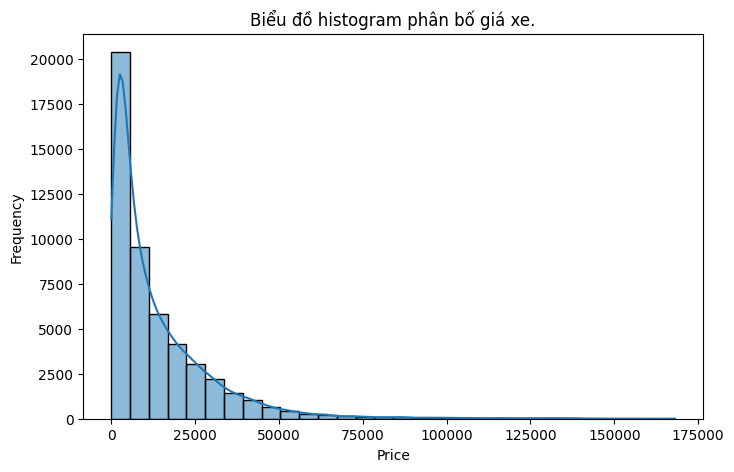

In [113]:
# ============================================
# PRICE DISTRIBUTION
# ============================================

plt.figure(figsize=(8,5))

sns.histplot(df['Price'], bins=30, kde=True)

plt.title("Biểu đồ histogram phân bố giá xe.")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()


Phân tích: Biểu đồ cho thấy giá xe phân bố không đồng đều. Do đó cần chuyển đổi thành các nhóm giá để xây dựng bài toán phân loại.

#**# Stratified Train / Validation Split**
Phân tách biến mục tiêu và feature

Dữ liệu được chia thành:

- Training Set (80%)
- Validation Set (20%)



# Phân tách đặc trưng và biến mục tiêu

In [114]:
# ============================================
# 2.2 FEATURE / TARGET SEPARATION
# ============================================

# Biến mục tiêu (Target)
y_raw = df["Price"]

# Các đặc trưng đầu vào (Features)
X_raw = df.drop(columns=["Price"])

print("=" * 60)
print("FEATURE / TARGET INFORMATION")
print("=" * 60)

print(f"Kích thước X_raw: {X_raw.shape}")
print(f"Kích thước y_raw: {y_raw.shape}")

FEATURE / TARGET INFORMATION
Kích thước X_raw: (50000, 6)
Kích thước y_raw: (50000,)


# Chia tập train / test

In [115]:
# ============================================
# 2.3 STRATIFIED TRAIN / VALIDATION SPLIT
# ============================================

# Tạo temporary bins để stratify cho dữ liệu liên tục
temp_bins = pd.qcut(
    y_raw,
    q=3,
    labels=False
)

X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(
    X_raw,
    y_raw,
    test_size=0.2,
    random_state=SEED,
    stratify=temp_bins
)

print("=" * 60)
print("TRAIN / VALIDATION SPLIT")
print("=" * 60)

print(f"Kích thước tập Train: {X_train_raw.shape}")
print(f"Kích thước tập Validation: {X_val_raw.shape}")

TRAIN / VALIDATION SPLIT
Kích thước tập Train: (40000, 6)
Kích thước tập Validation: (10000, 6)




Do biến Price là biến liên tục nên không thể áp dụng stratify trực tiếp.

Vì vậy, temporary quantile bins được tạo ra nhằm:
- duy trì phân phối dữ liệu tương đối đồng đều,
- giảm hiện tượng lệch phân phối giữa Train và Validation,
- giúp mô hình học ổn định hơn.





#**# SECTION 3. FEATURE ENGINEERING & SCALING**

### 1. Quantile Binning

Để chuyển bài toán thành phân loại 3 lớp (Low, Medium, High), hai ngưỡng phân vị $Q_{33.3\%}$ và $Q_{66.6\%}$ được tính **chỉ trên tập Train** nhằm đảm bảo không rò rỉ dữ liệu. Sau đó, các ngưỡng này được áp dụng cho cả Train và Validation.

### 2. One-Hot Encoding & Alignment

Các biến phân loại được chuyển thành dạng One-Hot Encoding.  
Phương thức `.align()` được sử dụng để đảm bảo tập Validation có cùng cấu trúc cột với tập Train, tránh sai lệch kích thước đầu vào của mô hình.

### 3. Standardization (Z-Score)

Do các đặc trưng có thang đo khác nhau, dữ liệu được chuẩn hóa bằng `StandardScaler`.  
Bộ chuẩn hóa chỉ được `fit` trên tập Train và sau đó được dùng để `transform` tập Validation nhằm đảm bảo tính chống rò rỉ dữ liệu.

# 3.1 LABEL ENGINEERING & QUANTILE BINNING

In [116]:
# ============================================
# 3.1.1 LABEL ENGINEERING & QUANTILE BINNING
# ============================================

# Định nghĩa tên lớp
CLASS_NAMES = {
    0: "Low",
    1: "Medium",
    2: "High"
}

NUM_CLASSES = 3


# --------------------------------------------
# Tính quantile chỉ trên tập Train (Anti-Leakage)
# --------------------------------------------
q1_train = y_train_raw.quantile(0.3333)
q2_train = y_train_raw.quantile(0.6666)

print("=" * 60)
print("QUANTILE THRESHOLDS")
print("=" * 60)

print(f"Ngưỡng Low Class (q1): {q1_train:.2f}")
print(f"Ngưỡng High Class (q2): {q2_train:.2f}")


# --------------------------------------------
# Hàm chuyển đổi giá xe sang nhãn lớp
# --------------------------------------------
def price_to_class(price):

    if price <= q1_train:
        return 0

    elif price <= q2_train:
        return 1

    else:
        return 2


# --------------------------------------------
# Áp dụng threshold từ Train sang Validation
# --------------------------------------------
y_train = y_train_raw.apply(price_to_class).values
y_val = y_val_raw.apply(price_to_class).values


print("\nClass Labels:")
print(CLASS_NAMES)

QUANTILE THRESHOLDS
Ngưỡng Low Class (q1): 4286.00
Ngưỡng High Class (q2): 14314.33

Class Labels:
{0: 'Low', 1: 'Medium', 2: 'High'}


## Giải thích Anti-Leakage

Các ngưỡng quantile chỉ được tính trên tập Train nhằm tránh hiện tượng Data Leakage.

Validation Set không được tham gia vào quá trình xác định ngưỡng phân lớp để đảm bảo tính khách quan khi đánh giá mô hình.

# LABEL DISTRIBUTION VISUALIZATION

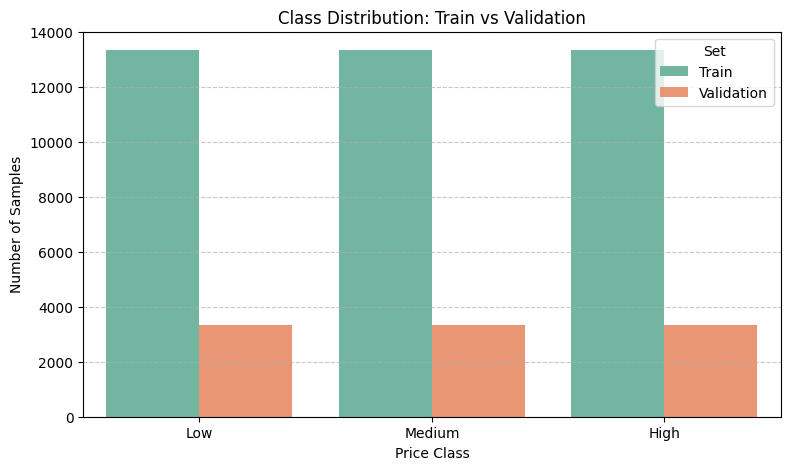

In [117]:
# ============================================
# 3.1.2 LABEL DISTRIBUTION VISUALIZATION
# ============================================

df_train_labels = pd.DataFrame({
    "Price_Class": y_train,
    "Set": "Train"
})

df_val_labels = pd.DataFrame({
    "Price_Class": y_val,
    "Set": "Validation"
})

df_combined_labels = pd.concat([
    df_train_labels,
    df_val_labels
])

df_combined_labels["Class_Name"] = (
    df_combined_labels["Price_Class"]
    .map(CLASS_NAMES)
)

plt.figure(figsize=(9, 5))

sns.countplot(
    x="Class_Name",
    hue="Set",
    data=df_combined_labels,
    order=["Low", "Medium", "High"],
    palette="Set2"
)

plt.title("Class Distribution: Train vs Validation")
plt.xlabel("Price Class")
plt.ylabel("Number of Samples")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.7
)

plt.show()

# LABEL DISTRIBUTION STATISTICS

In [118]:
# ============================================
# 3.1.3 LABEL DISTRIBUTION STATISTICS
# ============================================

print("=" * 60)
print("TRAIN LABEL DISTRIBUTION")
print("=" * 60)

print(
    pd.Series(y_train)
    .value_counts(normalize=True)
    .rename(CLASS_NAMES)
)

print("\n")

print("=" * 60)
print("VALIDATION LABEL DISTRIBUTION")
print("=" * 60)

print(
    pd.Series(y_val)
    .value_counts(normalize=True)
    .rename(CLASS_NAMES)
)

TRAIN LABEL DISTRIBUTION
High      0.333400
Low       0.333375
Medium    0.333225
Name: proportion, dtype: float64


VALIDATION LABEL DISTRIBUTION
Low       0.3334
Medium    0.3333
High      0.3333
Name: proportion, dtype: float64


 # 3.2 ONE-HOT ENCODING



One-Hot Encoding được sử dụng để chuyển đổi các biến phân loại sang dạng số nhằm phù hợp với mô hình MLP.

Hàm `align()` được sử dụng nhằm:
- đảm bảo Train và Validation có cùng số lượng đặc trưng,
- đồng bộ thứ tự cột,
- tránh lỗi dimension mismatch khi inference.

Các category không xuất hiện trong Validation sẽ được điền giá trị 0.

Dữ liệu được chuyển sang float32 nhằm tối ưu bộ nhớ và tương thích với PyTorch Tensor.

In [119]:
# ============================================
# 3.2.1 ONE-HOT ENCODING
# ============================================
X_train_encoded = pd.get_dummies(X_train_raw)
X_val_encoded = pd.get_dummies(X_val_raw)

# Căn chỉnh để tập Validation có số cột trùng khớp 100% với tập Train
X_train_encoded, X_val_encoded = X_train_encoded.align(
    X_val_encoded, join="left", axis=1, fill_value=0
)

# Đảm bảo định dạng số thực Float32 cho PyTorch
X_train_arr = X_train_encoded.values.astype(np.float32)
X_val_arr = X_val_encoded.values.astype(np.float32)



In [120]:
# ============================================
# 3.2.2 KIỂM TRA KẾT QUẢ ONE-HOT ENCODING
# ============================================

print("=" * 60)
print("KIỂM TRA DỮ LIỆU SAU ONE-HOT ENCODING")
print("=" * 60)

print(f"Số chiều X_train_encoded: {X_train_encoded.shape}")
print(f"Số chiều X_val_encoded:   {X_val_encoded.shape}")

print("\nKiểm tra số lượng cột:")
print(f"Train columns: {len(X_train_encoded.columns)}")
print(f"Validation columns: {len(X_val_encoded.columns)}")

print("\nKiểm tra kiểu dữ liệu:")
print(f"Train dtype: {X_train_arr.dtype}")
print(f"Validation dtype: {X_val_arr.dtype}")

print("\nKiểm tra căn chỉnh cột:")
print(
    "Hai tập dữ liệu đã đồng bộ số lượng và thứ tự đặc trưng:",
    list(X_train_encoded.columns) == list(X_val_encoded.columns)
)

KIỂM TRA DỮ LIỆU SAU ONE-HOT ENCODING
Số chiều X_train_encoded: (40000, 26)
Số chiều X_val_encoded:   (10000, 26)

Kiểm tra số lượng cột:
Train columns: 26
Validation columns: 26

Kiểm tra kiểu dữ liệu:
Train dtype: float32
Validation dtype: float32

Kiểm tra căn chỉnh cột:
Hai tập dữ liệu đã đồng bộ số lượng và thứ tự đặc trưng: True


# 3.3 FEATURE NORMALIZATION

In [121]:
# ============================================
# 3.3 FEATURE NORMALIZATION
# ============================================

scaler = StandardScaler()

# Fit chỉ trên Train
X_train_scaled = scaler.fit_transform(X_train_arr)

# Transform Validation dựa trên Train
X_val_scaled = scaler.transform(X_val_arr)

print("=" * 60)
print("FEATURE NORMALIZATION")
print("=" * 60)

print(f"Train Shape: {X_train_scaled.shape}")
print(f"Validation Shape: {X_val_scaled.shape}")

print("=" * 60)
print("XUẤT RA 5 DONG DAU TIEN SAU KHI CHUAN HOA")
print("=" * 60)

print('5 dòng đầu tiên của X_train_scaled:')
print(X_train_scaled[:5])

print('\n5 dòng đầu tiên của X_val_scaled:')
print(X_val_scaled[:5])

FEATURE NORMALIZATION
Train Shape: (40000, 26)
Validation Shape: (10000, 26)
XUẤT RA 5 DONG DAU TIEN SAU KHI CHUAN HOA
5 dòng đầu tiên của X_train_scaled:
[[ 0.3134 -0.1269 -0.5384 -0.3322  1.5241 -0.2337 -0.5777 -0.6509 -0.1329
  -0.1338 -0.1309 -0.333  -0.3331 -0.337  -0.184   2.9794 -0.3266 -0.3319
  -0.304  -0.3057 -0.1839 -0.2953 -0.1874  1.6653 -0.5388 -1.0202]
 [-0.5059  0.08   -0.077  -0.3322  1.5241 -0.2337 -0.5777 -0.6509 -0.1329
  -0.1338 -0.1309  3.0029 -0.3331 -0.337  -0.184  -0.3356 -0.3266 -0.3319
  -0.304  -0.3057 -0.1839 -0.2953 -0.1874 -0.6005 -0.5388  0.9802]
 [ 0.0403 -0.7478  0.3964 -0.3322 -0.6561 -0.2337 -0.5777  1.5363 -0.1329
  -0.1338 -0.1309 -0.333  -0.3331  2.9675 -0.184  -0.3356 -0.3266 -0.3319
  -0.304  -0.3057 -0.1839 -0.2953 -0.1874  1.6653 -0.5388 -1.0202]
 [ 4.41    0.5974 -0.1433  3.01   -0.6561 -0.2337 -0.5777 -0.6509 -0.1329
  -0.1338 -0.1309 -0.333  -0.3331 -0.337   5.4346 -0.3356 -0.3266 -0.3319
  -0.304  -0.3057 -0.1839 -0.2953 -0.1874 -0.6005 -0

In [122]:
# ============================================
# SCALING VERIFICATION
# ============================================

print("=" * 60)
print("SCALING STATISTICS")
print("=" * 60)

print(f"Train Mean: {np.mean(X_train_scaled):.4f}")
print(f"Train Std: {np.std(X_train_scaled):.4f}")

SCALING STATISTICS
Train Mean: 0.0000
Train Std: 1.0000


#**# SECTION 4. TENSOR CONVERSION & DATALOADER**

### 1. Chuyển đổi sang Tensor

Dữ liệu được chuyển từ NumPy sang `torch.Tensor` để tương thích với PyTorch.  
Đặc trưng đầu vào được ép kiểu `float32` nhằm tối ưu tính toán, trong khi nhãn được ép kiểu `long (int64)` để phù hợp với hàm mất mát `CrossEntropyLoss`.

### 2. Thiết lập DataLoader

`DataLoader` được sử dụng để tạo các mini-batch với kích thước **Batch Size = 32**, giúp cân bằng giữa tốc độ huấn luyện và độ ổn định gradient.  

Thuộc tính `shuffle=True` chỉ được áp dụng cho tập Train nhằm đảm bảo tính ngẫu nhiên trong quá trình học, trong khi tập Validation không được xáo trộn.

In [123]:
# ============================================
# 4.1 NUMPY ARRAY TO PYTORCH TENSOR CONVERSION
# ============================================
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

# ============================================
# 4.2 MINI-BATCH DATALOADER SETUP
# ============================================
BATCH_SIZE = 32  # Tối ưu hóa giữa tốc độ hội tụ và độ ổn định Gradient

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Hệ thống DataLoader sẵn sàng!")
print(f"Số lượng Batches trên tập Huấn luyện: {len(train_loader)}")
print(f"Số lượng Batches trên tập Kiểm định: {len(val_loader)}")


Hệ thống DataLoader sẵn sàng!
Số lượng Batches trên tập Huấn luyện: 1250
Số lượng Batches trên tập Kiểm định: 313


#**# SECTION 5. MLP ARCHITECTURE**

Mô hình được xây dựng kế thừa từ `nn.Module`, gồm:

- **Input Layer:** Kích thước phụ thuộc vào số đặc trưng sau One-Hot Encoding.
- **Hidden Layer 1:** 128 neurons + ReLU + Dropout.
- **Hidden Layer 2:** 64 neurons + ReLU + Dropout.
- **Output Layer:** 3 neurons (tương ứng 3 lớp), trả về logits.

### ReLU Activation

ReLU được sử dụng để tạo tính phi tuyến cho mô hình, giúp học các quan hệ phức tạp trong dữ liệu và hạn chế hiện tượng vanishing gradient.

### Dropout Regularization

Dropout được áp dụng trong quá trình huấn luyện nhằm giảm overfitting bằng cách ngẫu nhiên tắt một phần neuron, giúp tăng khả năng tổng quát hóa.

### Lưu ý về Softmax

Không sử dụng Softmax ở tầng cuối vì `nn.CrossEntropyLoss()` đã bao gồm LogSoftmax bên trong, do đó mô hình chỉ cần xuất ra logits.

# Cấu hình tham số

In [124]:
# ============================================
# 5.1 HYPERPARAMETERS CONFIGURATION
# ============================================

# Training Configuration
EPOCHS = 50
LEARNING_RATE = 0.001
BATCH_SIZE = 64

# Model Architecture
HIDDEN_DIM_1 = 128
HIDDEN_DIM_2 = 64
DROPOUT_RATE = 0.3

# Optimizer
OPTIMIZER_NAME = "Adam"

# Loss Function
LOSS_FUNCTION = "CrossEntropyLoss"

# Scheduler
LR_SCHEDULER_PATIENCE= 5
LR_SCHEDULER_FACTOR = 0.5

NUM_CLASSES=3

print("=" * 60)
print("HYPERPARAMETERS CONFIGURATION")
print("=" * 60)

print(f"EPOCHS: {EPOCHS}")
print(f"LEARNING_RATE: {LEARNING_RATE}")
print(f"BATCH_SIZE: {BATCH_SIZE}")

print(f"HIDDEN_DIM_1: {HIDDEN_DIM_1}")
print(f"HIDDEN_DIM_2: {HIDDEN_DIM_2}")

print(f"DROPOUT_RATE: {DROPOUT_RATE}")

print(f"OPTIMIZER: {OPTIMIZER_NAME}")
print(f"LOSS FUNCTION: {LOSS_FUNCTION}")

HYPERPARAMETERS CONFIGURATION
EPOCHS: 50
LEARNING_RATE: 0.001
BATCH_SIZE: 64
HIDDEN_DIM_1: 128
HIDDEN_DIM_2: 64
DROPOUT_RATE: 0.3
OPTIMIZER: Adam
LOSS FUNCTION: CrossEntropyLoss


# Kiến trúc MLP

In [127]:
# ============================================
# 5.2 MLP ARCHITECTURE
# ============================================

class CarPriceMLP(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_dim_1=HIDDEN_DIM_1,
        hidden_dim_2=HIDDEN_DIM_2,
        dropout_rate=DROPOUT_RATE,
        num_classes=NUM_CLASSES
    ):

        super(CarPriceMLP, self).__init__()

        self.network = nn.Sequential(

            # ====================================
            # HIDDEN LAYER 1
            # ====================================

            nn.Linear(input_dim, hidden_dim_1),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # ====================================
            # HIDDEN LAYER 2
            # ====================================

            nn.Linear(hidden_dim_1, hidden_dim_2),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # ====================================
            # OUTPUT LAYER
            # ====================================

            nn.Linear(hidden_dim_2, num_classes)
        )

        # ====================================
        # KAIMING WEIGHT INITIALIZATION
        # ====================================

        self._initialize_weights()

    def _initialize_weights(self):

        for layer in self.network:

            if isinstance(layer, nn.Linear):

                nn.init.kaiming_normal_(layer.weight)

                if layer.bias is not None:

                    nn.init.zeros_(layer.bias)

    def forward(self, x):

        return self.network(x)
# Kh̉ơi tạo kỉêm th̉ư ćâu trúc mạng

print("=" * 60)
print("KIẾN TRÚC MLP ")
print("=" * 60)

input_features_dim = X_train_tensor.shape[1]
model_test = CarPriceMLP(input_dim=input_features_dim, dropout_rate=DROPOUT_RATE)
print(model_test)

KIẾN TRÚC MLP 
CarPriceMLP(
  (network): Sequential(
    (0): Linear(in_features=26, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=3, bias=True)
  )
)


#**# SECTION 6. TRAINING & VALIDATION ENGINE**

Mô hình được huấn luyện thông qua một hàm khung (`training loop`) nhằm đảm bảo quy trình thực nghiệm rõ ràng và tái lập.

### 1. Giai đoạn Huấn luyện

- Sử dụng `model.train()` để kích hoạt Dropout.
- Thực hiện lan truyền ngược (backpropagation) và cập nhật trọng số bằng optimizer Adam.
- Tính toán Loss trên tập Train.

### 2. Giai đoạn Kiểm định

- Sử dụng `model.eval()` để chuyển mô hình sang chế độ đánh giá.
- Kết hợp `torch.no_grad()` để tắt tính toán gradient.
- Dropout được vô hiệu hóa nhằm đảm bảo kết quả đánh giá ổn định và khách quan trên tập Validation.

#Định nghĩa Pipeline huấn luyện mô hình
Các bước chính bao gồm:

- Khởi tạo hàm mất mát `CrossEntropyLoss`
- Sử dụng `Adam Optimizer` để cập nhật trọng số
- Điều chỉnh Learning Rate bằng `ReduceLROnPlateau`
- Huấn luyện mô hình trên tập Train
- Đánh giá mô hình trên tập Validation
- Tính toán Loss và Accuracy cho từng Epoch
- Lưu lại mô hình có `Validation Loss` tốt nhất
- Theo dõi lịch sử huấn luyện để phục vụ trực quan hóa kết quả

In [ ]:
# ============================================
# 6.1 CORE PIPELINE ENGINE DEFINITION
# ============================================

def execute_training_loop(
    model,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    model_name="best_car_model.pth"
):

    # --------------------------------------------
    # Loss Function cho bài toán Classification
    # --------------------------------------------
    criterion = nn.CrossEntropyLoss()

    # --------------------------------------------
    # Adam Optimizer dùng cập nhật trọng số
    # --------------------------------------------
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # --------------------------------------------
    # Learning Rate Scheduler
    # Giảm LR khi Validation Loss không cải thiện
    # --------------------------------------------
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        patience=LR_SCHEDULER_PATIENCE,
        factor=LR_SCHEDULER_FACTOR
    )

    # Đưa model lên GPU/CPU
    model.to(device)

    # Lưu lịch sử huấn luyện
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    # Theo dõi model tốt nhất
    best_val_loss = float("inf")

    # ============================================
    # TRAINING LOOP
    # ============================================
    for epoch in range(epochs):

        # ==================================================
        # PHASE 1: TRAINING MODE
        # ==================================================

        # Kích hoạt chế độ train
        # Dropout sẽ được bật
        model.train()

        running_loss = 0.0
        correct_train = 0
        total_train = 0

        # Duyệt từng batch dữ liệu
        for X_batch, y_batch in train_loader:

            # Đưa dữ liệu lên GPU/CPU
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            # Reset gradient trước mỗi lần update
            optimizer.zero_grad()

            # Forward Propagation
            outputs = model(X_batch)

            # Tính Loss
            loss = criterion(outputs, y_batch)

            # Backpropagation
            loss.backward()

            # Cập nhật trọng số
            optimizer.step()

            # Tính tổng train loss
            running_loss += loss.item() * X_batch.size(0)

            # Lấy class prediction
            preds = torch.argmax(outputs, dim=1)

            # Tính accuracy
            correct_train += (preds == y_batch).sum().item()
            total_train += y_batch.size(0)

        # ==================================================
        # PHASE 2: VALIDATION MODE
        # ==================================================

        # Chuyển sang chế độ đánh giá
        # Dropout sẽ bị tắt
        model.eval()

        running_val_loss = 0.0
        correct_val = 0
        total_val = 0

        # Tắt gradient để tiết kiệm bộ nhớ
        with torch.no_grad():

            for X_batch, y_batch in val_loader:

                # Đưa dữ liệu lên GPU/CPU
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                # Forward Propagation
                outputs = model(X_batch)

                # Tính Validation Loss
                loss = criterion(outputs, y_batch)

                # Tính tổng validation loss
                running_val_loss += loss.item() * X_batch.size(0)

                # Lấy class prediction
                preds = torch.argmax(outputs, dim=1)

                # Tính validation accuracy
                correct_val += (preds == y_batch).sum().item()
                total_val += y_batch.size(0)

        # ==================================================
        # METRIC CALCULATION
        # ==================================================

        # Tính trung bình Loss và Accuracy
        epoch_train_loss = running_loss / total_train
        epoch_val_loss = running_val_loss / total_val

        epoch_train_acc = correct_train / total_train
        epoch_val_acc = correct_val / total_val

        # ==================================================
        # LEARNING RATE SCHEDULER
        # ==================================================

        # Giảm Learning Rate nếu Val Loss không cải thiện
        scheduler.step(epoch_val_loss)

        # ==================================================
        # SAVE BEST MODEL
        # ==================================================

        # Lưu model có Validation Loss tốt nhất
        if epoch_val_loss < best_val_loss:

            best_val_loss = epoch_val_loss

            torch.save(
                model.state_dict(),
                model_name
            )

        # ==================================================
        # SAVE TRAINING HISTORY
        # ==================================================

        history["train_loss"].append(epoch_train_loss)
        history["val_loss"].append(epoch_val_loss)

        history["train_acc"].append(epoch_train_acc)
        history["val_acc"].append(epoch_val_acc)

        # ==================================================
        # DISPLAY TRAINING RESULT
        # ==================================================

        if (epoch + 1) % 10 == 0 or epoch == 0:

            # Lấy Learning Rate hiện tại
            current_lr = optimizer.param_groups[0]['lr']

            print(
                f"Epoch [{epoch+1:02d}/{epochs}] | "
                f"LR: {current_lr:.6f} -> "
                f"Train Loss: {epoch_train_loss:.4f} | "
                f"Acc: {epoch_train_acc:.4f} || "
                f"Val Loss: {epoch_val_loss:.4f} | "
                f"Acc: {epoch_val_acc:.4f}"
            )

    return history

#**# SECTION 7. EXPERIMENTAL ANALYSIS: WITH vs WITHOUT DROPOUT**

### 1. Mục tiêu thực nghiệm

Thực hiện so sánh hai mô hình có cấu hình siêu tham số giống nhau:

- Learning Rate = 0.001  
- Epochs = 50  
- Optimizer = Adam  

Điểm khác biệt duy nhất là:

1. Mô hình không sử dụng Dropout (`dropout_rate = 0.0`)
2. Mô hình có sử dụng Dropout (`dropout_rate = 0.3`)

### 2. Phân tích Learning Curves

Vẽ biểu đồ Loss và Accuracy của hai mô hình trên cùng một không gian để đánh giá hiện tượng overfitting và vai trò của Dropout trong việc cải thiện khả năng tổng quát hóa.

# Huấn luyện mô hình có Dropout và không Dropout

In [128]:
# ============================================
# 7.1 Huấn luyện mô hình chuẩn (Không Dropout)
# ============================================
print("--- KHỞI CHẠY THỰC NGHIỆM: MÔ HÌNH KHÔNG DROPOUT ---")
model_pure = CarPriceMLP(input_dim=input_features_dim, dropout_rate=0.0)
# Truyền thêm tên file lưu riêng cho mô hình pure
history_pure = execute_training_loop(model_pure, epochs=EPOCHS, lr=LEARNING_RATE, model_name="best_model_pure.pth")

# ============================================
# 7.2 Huấn luyện mô hình cải tiến (Có Dropout)
# ============================================
print("\n--- KHỞI CHẠY THỰC NGHIỆM: MÔ HÌNH CÓ DROPOUT (P=0.3) ---")
model_regularized = CarPriceMLP(input_dim=input_features_dim, dropout_rate=DROPOUT_RATE)

# Truyền thêm tên file lưu riêng cho mô hình regularized
history_reg = execute_training_loop(model_regularized, epochs=EPOCHS, lr=LEARNING_RATE, model_name="best_model_dropout.pth")

--- KHỞI CHẠY THỰC NGHIỆM: MÔ HÌNH KHÔNG DROPOUT ---
Epoch [01/50] | LR: 0.001000 -> Train Loss: 0.1319 | Acc: 0.9536 || Val Loss: 0.0655 | Acc: 0.9751
Epoch [10/50] | LR: 0.001000 -> Train Loss: 0.0318 | Acc: 0.9862 || Val Loss: 0.0510 | Acc: 0.9785
Epoch [20/50] | LR: 0.000500 -> Train Loss: 0.0174 | Acc: 0.9930 || Val Loss: 0.0177 | Acc: 0.9923
Epoch [30/50] | LR: 0.000250 -> Train Loss: 0.0155 | Acc: 0.9932 || Val Loss: 0.0191 | Acc: 0.9921
Epoch [40/50] | LR: 0.000250 -> Train Loss: 0.0088 | Acc: 0.9965 || Val Loss: 0.0134 | Acc: 0.9948
Epoch [50/50] | LR: 0.000250 -> Train Loss: 0.0083 | Acc: 0.9966 || Val Loss: 0.0102 | Acc: 0.9951

--- KHỞI CHẠY THỰC NGHIỆM: MÔ HÌNH CÓ DROPOUT (P=0.3) ---
Epoch [01/50] | LR: 0.001000 -> Train Loss: 0.3170 | Acc: 0.8630 || Val Loss: 0.0811 | Acc: 0.9748
Epoch [10/50] | LR: 0.001000 -> Train Loss: 0.0497 | Acc: 0.9794 || Val Loss: 0.0303 | Acc: 0.9881
Epoch [20/50] | LR: 0.001000 -> Train Loss: 0.0391 | Acc: 0.9838 || Val Loss: 0.0253 | Acc: 0.98

# 7.3 TRỰC QUAN HÓA LOSS VÀ ACCURACY CURVES

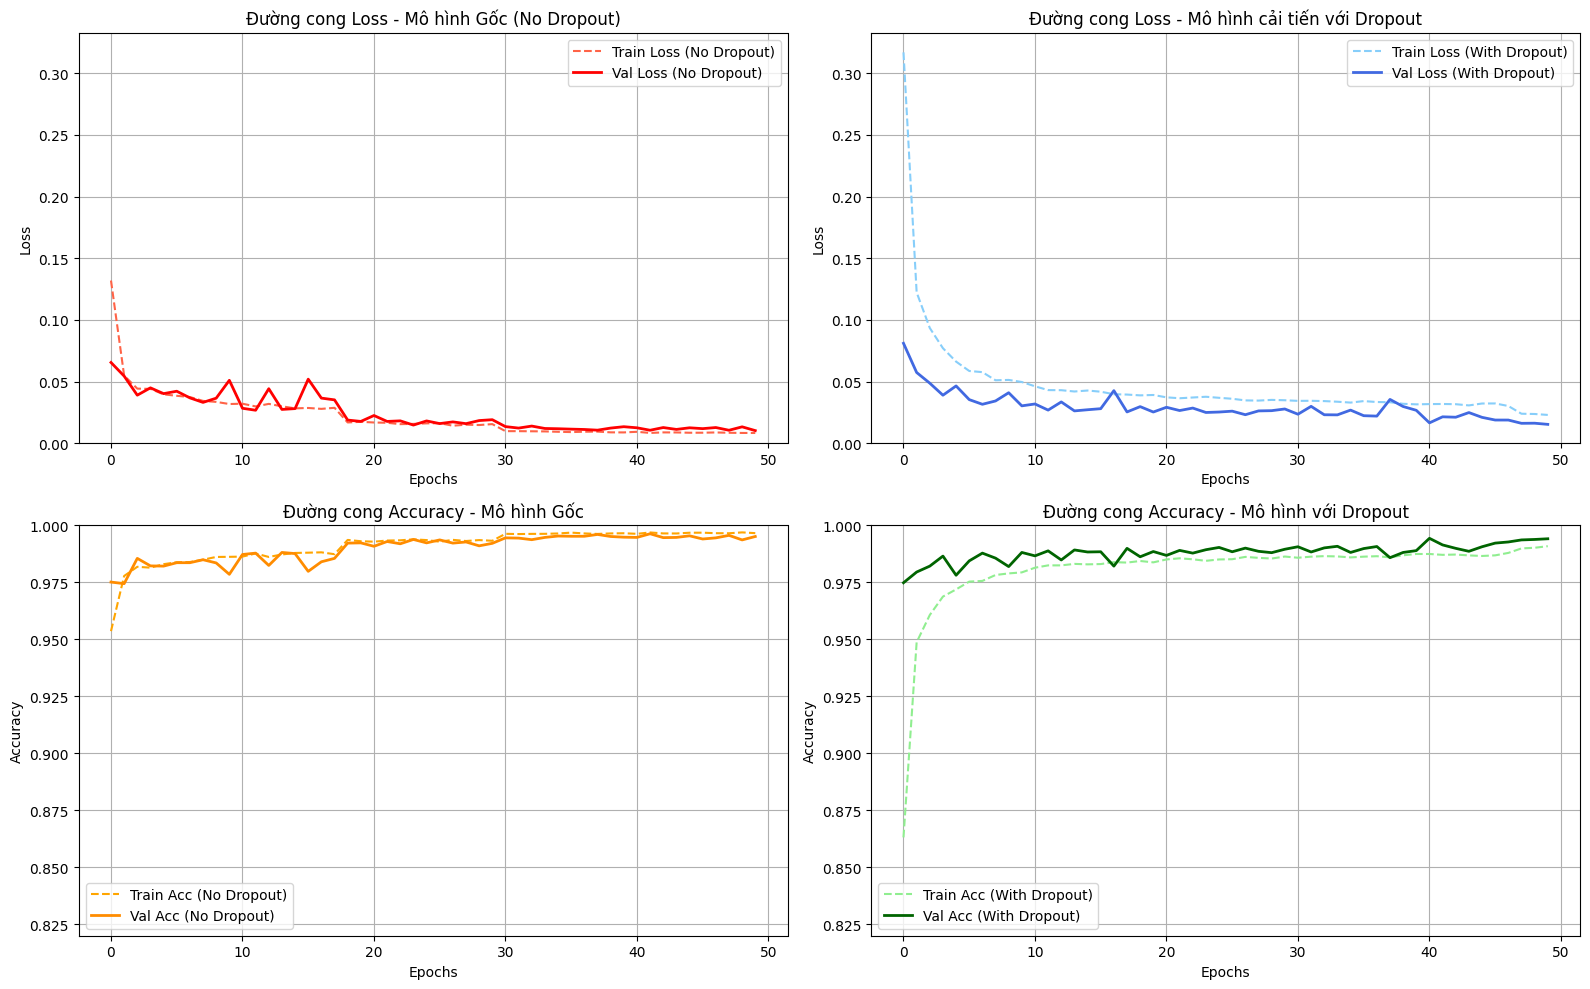

In [129]:
# ============================================
# 7.3 TRỰC QUAN HÓA SONG SONG CẢ LOSS VÀ ACCURACY CURVES
# ============================================
plt.figure(figsize=(16, 10))

# Tự động tìm điểm cao nhất/thấp nhất để đồng bộ các trục Y giúp so sánh chính xác
max_loss = max(max(history_pure['train_loss']), max(history_reg['train_loss'])) * 1.05
min_acc = min(min(history_pure['train_acc']), min(history_reg['train_acc'])) * 0.95

# --- KHỐI 1: ĐƯỜNG CONG LOSS  ---
# Mô hình Gốc (Tông màu Đỏ/Cam)
plt.subplot(2, 2, 1)
plt.plot(history_pure['train_loss'], label='Train Loss (No Dropout)', linestyle='--', color='tomato')
plt.plot(history_pure['val_loss'], label='Val Loss (No Dropout)', linewidth=2, color='red')
plt.title('Đường cong Loss - Mô hình Gốc (No Dropout)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.ylim(0, max_loss) # Đồng bộ trục Y
plt.legend()
plt.grid(True)

# Mô hình Cải tiến (Tông màu Xanh dương)
plt.subplot(2, 2, 2)
plt.plot(history_reg['train_loss'], label='Train Loss (With Dropout)', linestyle='--', color='lightskyblue')
plt.plot(history_reg['val_loss'], label='Val Loss (With Dropout)', linewidth=2, color='royalblue')
plt.title('Đường cong Loss - Mô hình cải tiến với Dropout')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.ylim(0, max_loss) # Đồng bộ trục Y
plt.legend()
plt.grid(True)


# --- KHỐI 2: ĐƯỜNG CONG ACCURACY  ---
# Mô hình Gốc
plt.subplot(2, 2, 3)
plt.plot(history_pure['train_acc'], label='Train Acc (No Dropout)', linestyle='--', color='orange')
plt.plot(history_pure['val_acc'], label='Val Acc (No Dropout)', linewidth=2, color='darkorange')
plt.title('Đường cong Accuracy - Mô hình Gốc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.ylim(min_acc, 1.0) # Đồng bộ trục Y từ min_acc đến 100%
plt.legend()
plt.grid(True)

# Mô hình Cải tiến
plt.subplot(2, 2, 4)
plt.plot(history_reg['train_acc'], label='Train Acc (With Dropout)', linestyle='--', color='lightgreen')
plt.plot(history_reg['val_acc'], label='Val Acc (With Dropout)', linewidth=2, color='darkgreen')
plt.title('Đường cong Accuracy - Mô hình với Dropout')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.ylim(min_acc, 1.0) # Đồng bộ trục Y từ min_acc đến 100%
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Nhận xét kết quả huấn luyện mô hình


Biểu đồ cho thấy cả hai mô hình đều đạt hiệu năng rất cao trong bài toán phân loại mức giá xe.

- Giá trị Loss của cả tập Train và Validation đều giảm dần theo số Epoch, cho thấy mô hình học ổn định và hội tụ tốt.
- Accuracy của mô hình đạt gần 99% trên cả Train và Validation, chứng tỏ khả năng phân loại hiệu quả.
- Mô hình cải tiến sử dụng Dropout có đường cong học ổn định hơn và giúp giảm nguy cơ Overfitting.
- Khoảng cách giữa Train Accuracy và Validation Accuracy nhỏ, cho thấy mô hình có khả năng tổng quát hóa tốt trên dữ liệu chưa thấy trước đó.

Kết quả thực nghiệm cho thấy việc áp dụng kỹ thuật Dropout giúp cải thiện tính ổn định của mô hình mà vẫn duy trì độ chính xác cao trong bài toán dự đoán giá xe.

#**# SECTION 8. PERFORMANCE EVALUATION**

### 1. Mục tiêu đánh giá

Mô hình được lựa chọn (phiên bản có Dropout) được sử dụng để dự đoán trên tập Validation độc lập nhằm đánh giá khả năng tổng quát hóa.

### 2. Classification Report

Sử dụng `Classification Report` để tính các chỉ số:

- **Precision**: Độ chính xác của dự đoán.
- **Recall**: Khả năng phát hiện đúng từng lớp.
- **F1-Score**: Trung bình điều hòa giữa Precision và Recall.

### 3. Confusion Matrix

Ma trận nhầm lẫn được sử dụng để phân tích chi tiết mức độ dự đoán đúng/sai giữa các lớp, đặc biệt tại ranh giới giữa các phân khúc giá.

### 4. Precision-Recall Curve

Đường cong Precision-Recall được vẽ để phân tích sự đánh đổi giữa Precision và Recall khi thay đổi ngưỡng quyết định.  
Chỉ số **Average Precision (AP)** được tính để đánh giá hiệu năng tổng thể của mô hình đối với từng lớp.

# LOAD BEST MODEL & GENERATE PREDICTIONS

In [130]:
# ============================================
# 8.1.1 LOAD BEST MODEL
# ============================================

try:
    model_regularized.load_state_dict(torch.load("best_model_dropout.pth"))
    print("Successfully loaded the BEST weights for Evaluation!")
except FileNotFoundError:
    print("Warning: 'best_model_dropout.pth' not found. Using current weights instead.")

model_regularized.to(device)
model_regularized.eval()

Successfully loaded the BEST weights for Evaluation!


CarPriceMLP(
  (network): Sequential(
    (0): Linear(in_features=26, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=3, bias=True)
  )
)

In [131]:
# ============================================
# 8.1.2 GENERATE INFERENCE PREDICTIONS
# ============================================

all_predictions = []
all_true_labels = []
all_probabilities = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:

        X_batch = X_batch.to(device)

        outputs = model_regularized(X_batch)

        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_predictions.extend(preds.cpu().numpy())
        all_true_labels.extend(y_batch.numpy())
        all_probabilities.extend(probs.cpu().numpy())

y_pred = np.array(all_predictions)
y_true = np.array(all_true_labels)
y_prob = np.array(all_probabilities)

print("Inference completed successfully!")

Inference completed successfully!


#  CLASSIFICATION REPORT

In [132]:
# ============================================
# 8.3 CLASSIFICATION REPORT
# ============================================

target_names = ["Thấp (Low)", "Trung Bình (Medium)", "Cao (High)"]

print("\n" + "=" * 20 + " CLASSIFICATION REPORT " + "=" * 20)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=target_names
    )
)


==================== CLASSIFICATION REPORT ====================
                     precision    recall  f1-score   support

         Thấp (Low)       1.00      1.00      1.00      3334
Trung Bình (Medium)       0.99      0.99      0.99      3333
         Cao (High)       0.99      1.00      1.00      3333

           accuracy                           0.99     10000
          macro avg       0.99      0.99      0.99     10000
       weighted avg       0.99      0.99      0.99     10000



# nhận xét  kết quả Classification Report
Mô hình đạt độ chính xác tổng thể (Accuracy) khoảng 99% trên tập Validation.

Các chỉ số Precision, Recall và F1-Score của cả ba lớp đều nằm trong khoảng 0.98–1.00.

Macro Average và Weighted Average đều xấp xỉ 0.99, cho thấy hiệu năng ổn định giữa các lớp và không có sự mất cân bằng đáng kể.

# CONFUSION MATRIX VISUALIZATION

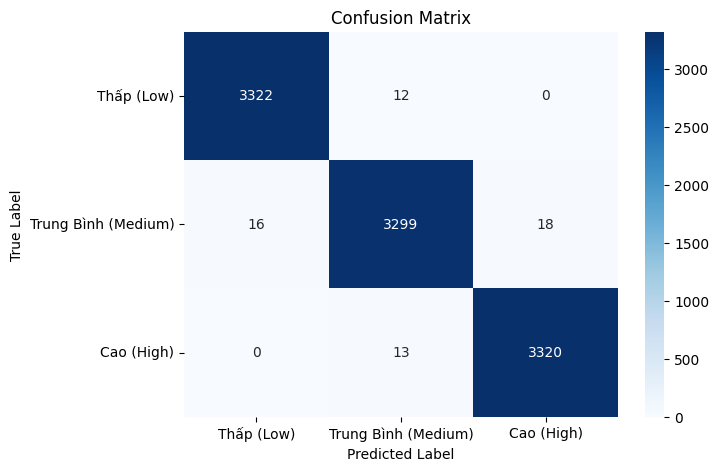

In [133]:
# ============================================
# 8.4 CONFUSION MATRIX VISUALIZATION
# ============================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.yticks(rotation=0)

plt.show()

# Nhận xét Confusion Matrix

Các giá trị trên đường chéo chính chiếm tỷ lệ lớn, cho thấy phần lớn mẫu được phân loại chính xác.
Lớp Medium có số lượng nhầm lẫn cao hơn so với hai lớp còn lại, đặc biệt ở ranh giới với lớp Low và High.
Điều này phản ánh sự giao thoa tự nhiên giữa các phân khúc giá trung bình với hai nhóm còn lại.
Hầu như không xuất hiện nhầm lẫn trực tiếp giữa hai lớp đối cực (Low và High).

# 8.5 PRECISION-RECALL CURVE ANALYSIS

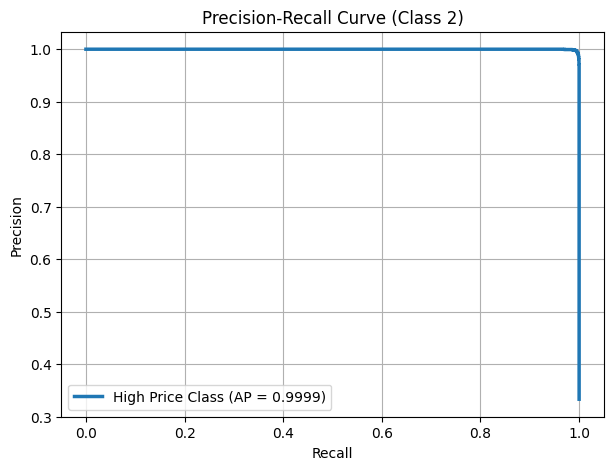

In [134]:
# ============================================
# 8.5 PRECISION-RECALL CURVE ANALYSIS
# ============================================

# One-vs-Rest analysis for High Price class (Class 2)
y_true_binary = (y_true == 2).astype(int)

y_scores_class2 = y_prob[:, 2]

precision, recall, _ = precision_recall_curve(
    y_true_binary,
    y_scores_class2
)

ap_score = average_precision_score(
    y_true_binary,
    y_scores_class2
)

plt.figure(figsize=(7, 5))

plt.plot(
    recall,
    precision,
    linewidth=2.5,
    label=f"High Price Class (AP = {ap_score:.4f})"
)

plt.title("Precision-Recall Curve (Class 2)")
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.legend(loc="lower left")

plt.grid(True)

plt.show()

## Nhận xét  Precision–Recall Curve (Class 2)

Average Precision (AP) đạt giá trị rất cao, gần 1.0.
Đường cong Precision–Recall duy trì gần sát góc trên bên phải của biểu đồ.
Kết quả này cho thấy mô hình duy trì được Precision cao trên hầu hết các mức Recall và có khả năng phân biệt lớp rất tốt.

# # Bảng thống kê các mốc ngưỡng

In [135]:
# =====================================================================
# IN BẢNG THỐNG KÊ CÁC MỐC NGƯỠNG TIÊU BIỂU
# =====================================================================
# Định nghĩa các mốc ngưỡng tin cậy (t) tiêu biểu mà chúng ta muốn xem tóm tắt
target_t = [0.4, 0.5, 0.6, 0.7, 0.8]

# Khởi tạo danh sách trống để lưu các hàng dữ liệu tìm được
summary_rows = []

# Duyệt qua từng mốc ngưỡng trong danh sách mục tiêu
for t in target_t:
    #  Tìm chỉ số (index) của hàng có giá trị Threshold gần mốc 't' nhất.
    # 1. Lấy cột Threshold trừ đi t để xem độ lệch.
    # 2. Dùng .abs() để chuyển các độ lệch âm thành dương (lấy khoảng cách thuần túy).
    # 3. Dùng .idxmin() để bốc ra vị trí dòng có khoảng cách nhỏ nhất (gần t nhất).
    idx = (df_threshold_analysis['Threshold'] - t).abs().idxmin()

    # Dựa vào chỉ số 'idx' vừa tìm được, bốc toàn bộ hàng dữ liệu đó ra và thêm vào danh sách
    summary_rows.append(df_threshold_analysis.loc[idx])

# Gộp các hàng dữ liệu đã bốc được thành một DataFrame mới và reset lại chỉ số dòng từ 0
df_summary = pd.DataFrame(summary_rows).reset_index(drop=True)

print("=== BẢNG PHÂN TÍCH SỰ ĐÁNH ĐỔI THEO NGƯỠNG TIN CẬY (MULTICLASS THRESHOLD ANALYSIS) ===")

# In DataFrame ra console dưới dạng chuỗi (string) sạch sẽ
print(df_summary.to_string(
    index=False, # Ẩn cột chỉ số dòng (0, 1, 2...) để bảng gọn gàng hơn
    formatters={
        'Threshold': '{:,.2f}'.format,
        'Precision (Macro)': '{:,.2%}'.format,
        'Recall (Macro)': '{:,.2%}'.format,
        'F1-Score (Macro)': '{:,.2%}'.format,
        'Data Coverage': '{:,.2%}'.format
    }
))

=== BẢNG PHÂN TÍCH SỰ ĐÁNH ĐỔI THEO NGƯỠNG TIN CẬY (MULTICLASS THRESHOLD ANALYSIS) ===
Threshold Precision (Macro) Recall (Macro) F1-Score (Macro) Data Coverage
     0.40            99.55%         99.55%           99.55%       100.00%
     0.50            99.55%         99.55%           99.55%       100.00%
     0.60            99.73%         99.73%           99.73%        99.66%
     0.69            99.85%         99.85%           99.85%        99.32%
     0.80            99.90%         99.90%           99.90%        98.90%


# KẾT QUẢ BẢNG PHÂN TÍCH NGƯỠNG

- Các chỉ số Precision, Recall và F1-Score đều duy trì ở mức rất cao (>99.5%) tại nhiều ngưỡng khác nhau, cho thấy mô hình có khả năng phân loại dữ liệu ổn định và hiệu quả.

- Khi tăng ngưỡng confidence từ 0.40 lên 0.80, độ chính xác của dự đoán có xu hướng cải thiện nhẹ, trong khi Data Coverage chỉ giảm không đáng kể.

- Ở các ngưỡng 0.69–0.80, mô hình đạt độ chính xác gần 99.9% và tỷ lệ dữ liệu cần kiểm tra thủ công vẫn ở mức thấp (khoảng 0.34%–1.10%).

- Vì vậy, ngưỡng 0.69 hoặc 0.80 có thể được xem là lựa chọn phù hợp để cân bằng giữa độ chính xác và khả năng tự động hóa của hệ thống.

# # Trực quan hóa sự đánh đổi trong đa lớp

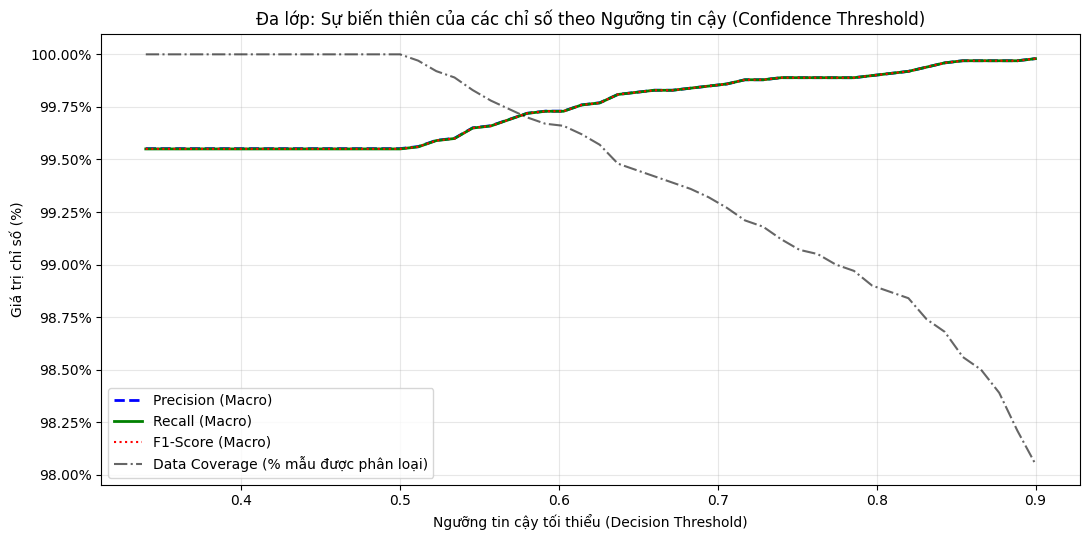

In [136]:
# =====================================================================
#  BIỂU ĐỒ TRỰC QUAN HÓA SỰ ĐÁNH ĐỔI TRONG ĐA LỚP
# =====================================================================
import matplotlib.ticker as mtick

plt.figure(figsize=(11, 5.5))
plt.plot(df_threshold_analysis['Threshold'], df_threshold_analysis['Precision (Macro)'], 'b--', label='Precision (Macro)', lw=2)
plt.plot(df_threshold_analysis['Threshold'], df_threshold_analysis['Recall (Macro)'], 'g-', label='Recall (Macro)', lw=2)
plt.plot(df_threshold_analysis['Threshold'], df_threshold_analysis['F1-Score (Macro)'], 'r:', label='F1-Score (Macro)', lw=1.5)
plt.plot(df_threshold_analysis['Threshold'], df_threshold_analysis['Data Coverage'], 'k-.', label='Data Coverage (% mẫu được phân loại)', alpha=0.6)

plt.title('Đa lớp: Sự biến thiên của các chỉ số theo Ngưỡng tin cậy (Confidence Threshold)')
plt.xlabel('Ngưỡng tin cậy tối thiểu (Decision Threshold)')
plt.ylabel('Giá trị chỉ số (%)') # Đổi nhãn thành %

# Định dạng trục Y hiển thị dạng % (ví dụ: 80% thay vì 0.8)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Nhận xét hiệu năng mô hình

- Mô hình đạt hiệu năng rất cao với Precision, Recall và F1-Score đều >99.5%, cho thấy khả năng phân loại chính xác và cân bằng giữa các lớp dữ liệu.

- Từ ngưỡng confidence 0.5 trở lên, mô hình xuất hiện sự đánh đổi giữa độ chính xác và độ bao phủ dữ liệu: chất lượng dự đoán tăng dần trong khi Data Coverage giảm nhẹ.

- Ở ngưỡng 0.9, độ bao phủ vẫn duy trì khoảng 98%, đồng thời các chỉ số đánh giá gần đạt 100%.

- Đề xuất sử dụng ngưỡng 0.7 - 0.8 trong thực tế để cân bằng giữa độ chính xác ( ~ 99.9% ) và khả năng tự động hóa (~99% dữ liệu).

## SECTION 9. CONCLUSION & FUTURE WORK

### 1. Kết luận

Đề tài đã xây dựng thành công pipeline phân loại giá xe theo hướng chống rò rỉ dữ liệu bằng cách tách Train/Validation trước khi tiền xử lý dữ liệu.

Mô hình MLP sử dụng ReLU và Dropout đạt độ chính xác khoảng 99% trên tập Validation, cho thấy khả năng học tốt và phân loại hiệu quả các phân khúc giá xe. Đồng thời, Dropout giúp mô hình ổn định hơn và cải thiện khả năng tổng quát hóa.

### 2. Ý nghĩa thực tiễn

Mô hình có thể ứng dụng trong các hệ thống phân loại và định giá xe tự động trên nền tảng thương mại điện tử.

### 3. Hướng phát triển

- Bổ sung Batch Normalization để cải thiện tốc độ hội tụ.
- Áp dụng Early Stopping nhằm giảm overfitting.
- Mở rộng thêm nhiều lớp phân loại giá xe.